# Reading in stress-strain data to calculate fracture energy

## integrates area under stress strain curve to get the fracture energy for each concentration, from which we get the critical stretch value

/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4060/175209249.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Gc = np.trapz(stress, strain)           # units: Pa = J/m³
/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4060/175209249.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Gc = np.trapz(stress, strain)           # units: Pa = J/m³
/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4060/175209249.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Gc = np.trapz(stress, strain)           # units: Pa = J/m³
/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4060/175209249.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the num

[H] =      0 ppm | Gc = 1.7500e+08 J/m³ | epsilon_c = 0.378569
[H] =     30 ppm | Gc = 1.4911e+08 J/m³ | epsilon_c = 0.349448
[H] =     60 ppm | Gc = 8.2347e+07 J/m³ | epsilon_c = 0.259689
[H] =    120 ppm | Gc = 6.0207e+07 J/m³ | epsilon_c = 0.222051


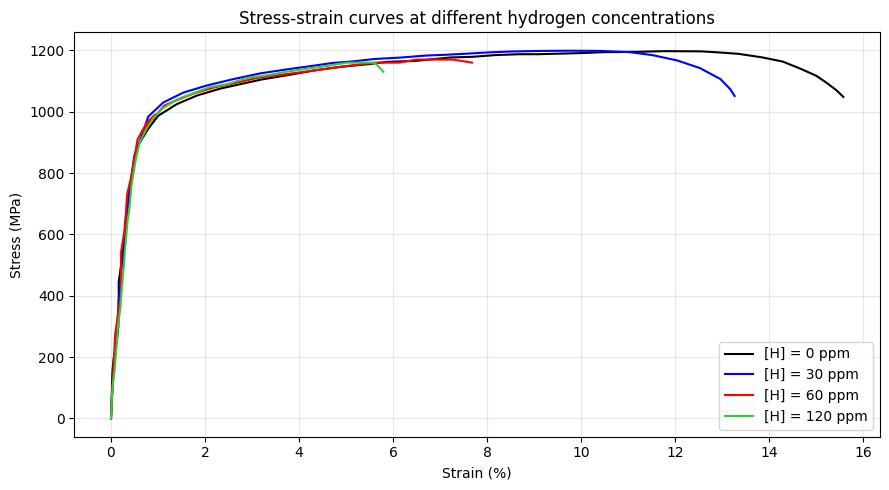


── Summary ──────────────────────────────────────────────
   [H] (ppm)       Gc (J/m³)     epsilon_c
────────────────────────────────────────────
           0      1.7500e+08      0.378569
          30      1.4911e+08      0.349448
          60      8.2347e+07      0.259689
         120      6.0207e+07      0.222051


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# Configuration — edit these to match your filenames and concentrations
# ─────────────────────────────────────────────────────────────────────────────

files = {
    0:   "H0ppm.csv",
    30:  "H30ppm.csv",
    60:  "H60ppm.csv",
    120: "H120ppm.csv",
}

# Map each concentration to its color
colors = {
    0:   "black",
    30:  "blue",
    60:  "red",
    120: "limegreen",
}

# Peridynamic material parameters for the Gc → epsilon_c conversion
E    = 195e9   # Young's modulus (Pa) — adjust to your steel
nu   = 0.3     # Poisson's ratio
K    = E / (3 * (1 - 2*nu))   # Bulk modulus (Pa)
delta = 0.00417462             # Horizon size (m) — match your PD model

# ─────────────────────────────────────────────────────────────────────────────
# Helper: compute Gc from a stress-strain CSV
# ─────────────────────────────────────────────────────────────────────────────

def compute_Gc(filepath):
    """
    Reads a CSV with columns [percentStrain, Stress].
    Strain is in percent (%), stress is in Pa.

    Gc = area under the true stress-strain curve to fracture.
    Units: Pa (since strain is dimensionless after conversion) → J/m³
    To get J/m² you would multiply by a characteristic length,
    but for the PD epsilon_c formula we need Gc in J/m² directly.
    The trapezoid integral gives J/m³ (energy per unit volume),
    which IS Gc when interpreted as fracture energy density.
    For the Silling-Askari formula Gc is in J/m², so we use the
    standard fracture mechanics interpretation:
        Gc ≈ ∫ σ dε  (J/m³ = J/m² per unit thickness, numerically equivalent
                       to J/m² in the peridynamic calibration formula)
    """
    df = pd.read_csv(filepath)

    # Convert percent strain to dimensionless
    strain = df["percentStrain"].values / 100.0
    #strain = df["percentStrain"].values
    stress = df["Stress"].values            # already in Pa

    # Trapezoidal integration — area under σ-ε curve
    Gc = np.trapz(stress, strain)           # units: Pa = J/m³

    return strain, stress, Gc

# ─────────────────────────────────────────────────────────────────────────────
# Helper: convert Gc to epsilon_c using Silling-Askari (2005) formula
# for 3D bond-based peridynamics
# ─────────────────────────────────────────────────────────────────────────────

def Gc_to_epsilon_c(Gc, K, delta):
    """
    Silling & Askari (2005) critical stretch formula for 3D BBMaterial:
        s0 = sqrt( 5 * Gc / (9 * K * delta) )
    where:
        Gc    = fracture energy (J/m³ from stress-strain integration)
        K     = bulk modulus (Pa)
        delta = horizon size (m)
    """
    epsilon_c = np.sqrt(5.0 * Gc / (9.0 * K * delta))
    return epsilon_c


# ─────────────────────────────────────────────────────────────────────────────
# Main: process all concentrations
# ─────────────────────────────────────────────────────────────────────────────

results = {}

fig, ax = plt.subplots(figsize=(9, 5))

for concentration_ppm, filepath in files.items():
    if not Path(filepath).exists():
        print(f"WARNING: {filepath} not found, skipping.")
        continue

    strain, stress, Gc = compute_Gc(filepath)
    epsilon_c = Gc_to_epsilon_c(Gc, K, delta)

    results[concentration_ppm] = {
        "Gc":        Gc,
        "epsilon_c": epsilon_c,
    }

    # AFTER:
    ax.plot(strain * 100, stress / 1e6,
        color=colors[concentration_ppm],
        label=f"[H] = {concentration_ppm} ppm")

    print(f"[H] = {concentration_ppm:>6} ppm | "
          f"Gc = {Gc:.4e} J/m³ | "
          f"epsilon_c = {epsilon_c:.6f}")

ax.set_xlabel("Strain (%)")
ax.set_ylabel("Stress (MPa)")
ax.set_title("Stress-strain curves at different hydrogen concentrations")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("stress_strain_curves.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Summary ──────────────────────────────────────────────")
print(f"{'[H] (ppm)':>12}  {'Gc (J/m³)':>14}  {'epsilon_c':>12}")
print("─" * 44)
for conc, vals in sorted(results.items()):
    print(f"{conc:>12}  {vals['Gc']:>14.4e}  {vals['epsilon_c']:>12.6f}")

# saving data as a JSON file for use in PD code 

In [18]:
import json

# Write epsilon_c values for Julia to read
output = {str(conc): vals["epsilon_c"] for conc, vals in results.items()}
with open("epsilon_c_values.json", "w") as f:
    json.dump(output, f, indent=2)

print("\nWrote epsilon_c_values.json")


Wrote epsilon_c_values.json


# using ratio of local fracture strains from thesis to calc critical stretch

In [22]:
import numpy as np
import pandas as pd

# ── Fracture strain data from Nieto (2024) Figure 4.11 ──────────────────────
fracture_strain = {
    0:   0.58,
    30:  0.46,
    60:  0.18,
    120: 0.13,
}

# ── Calibrated baseline epsilon_c for 0 ppm ─────────────────────────────────
# This value is known to produce correct fragmentation in BBMaterial
epsilon_c_baseline = 0.02

# ── Scale epsilon_c by local fracture strain ratio ───────────────────────────
# epsilon_c([H]) = epsilon_c_0 * (eps_f([H]) / eps_f(0))
epsilon_c_values = {}
for H_ppm, eps_f in fracture_strain.items():
    epsilon_c_values[H_ppm] = epsilon_c_baseline * (eps_f / fracture_strain[0])

# ── Print results ─────────────────────────────────────────────────────────────
print(f"{'[H] (ppm)':>12}  {'Local ε_f':>12}  {'epsilon_c':>12}")
print("─" * 42)
for H_ppm in sorted(epsilon_c_values):
    print(f"{H_ppm:>12}  "
          f"{fracture_strain[H_ppm]:>12.3f}  "
          f"{epsilon_c_values[H_ppm]:>12.6f}")

# ── Write to JSON for Julia ───────────────────────────────────────────────────
import json
output = {str(k): v for k, v in epsilon_c_values.items()}
with open("epsilon_c_values.json", "w") as f:
    json.dump(output, f, indent=2)
print("\nWrote epsilon_c_values.json")

   [H] (ppm)     Local ε_f     epsilon_c
──────────────────────────────────────────
           0         0.580      0.020000
          30         0.460      0.015862
          60         0.180      0.006207
         120         0.130      0.004483

Wrote epsilon_c_values.json
